# RecSys 2026 — Music-CRS: Exploratory Data Analysis

**Challenge:** Conversational Music Recommendation System  
**Dataset:** TalkPlayData-Challenge (`talkpl-ai/talkplay-data-challenge`)  

This notebook explores the dataset structure:
- Conversation statistics (turns, session lengths)
- Track metadata distribution (genres, artists, release years)
- User profile demographics
- Sample conversation display

In [3]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)

DATA_DIR = Path('../data/raw')
print('Setup complete ✅')

Setup complete ✅


## 1. Load Dataset

In [4]:
# Load conversation data directly from parquet
train_df = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Dataset/data/train-00000-of-00001.parquet')
dev_df = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Dataset/data/test-00000-of-00001.parquet')

print(f'Train: {train_df.shape} | Dev: {dev_df.shape}')
print(f'Columns: {list(train_df.columns)}')
train_df.head(3)

Train: (15199, 7) | Dev: (1000, 7)
Columns: ['session_id', 'user_id', 'session_date', 'user_profile', 'conversation_goal', 'conversations', 'goal_progress_assessments']


,session_id,user_id,session_date,user_profile,conversation_goal,conversations,goal_progress_assessments
0,9c337a02-15b1-408f-8103-c2f9459b3bed,64ea97af-bbc6-4756-ac94-b931048e5fef,2011-12-26,"{'age': 20, 'age_group': '20s', 'country_code': 'BR', 'country_name': 'Brazil', 'gender': 'female', 'preferred_langu...","{'category': 'H', 'listener_goal': 'The listener wants to explore different artists and discover new songs from a br...","[{'content': 'I want to discover some new artists. Do you have anything that's a bit intense or dramatic?', 'role': ...","[{'goal_progress_assessment': None, 'turn_number': 1}, {'goal_progress_assessment': 'MOVES_TOWARD_GOAL', 'turn_numbe..."
1,a43698ad-67a4-4552-b7b2-db602f40a043,64ea97af-bbc6-4756-ac94-b931048e5fef,2015-03-09,"{'age': 20, 'age_group': '20s', 'country_code': 'BR', 'country_name': 'Brazil', 'gender': 'female', 'preferred_langu...","{'category': 'K', 'listener_goal': 'discover multiple punk and alternative rock songs from the 2000s, exploring the ...","[{'content': 'I'm looking for some classic alternative rock with that early 2000s vibe.', 'role': 'user', 'thought':...","[{'goal_progress_assessment': None, 'turn_number': 1}, {'goal_progress_assessment': 'MOVES_TOWARD_GOAL', 'turn_numbe..."
2,3a0c7860-cbcf-432d-b6ab-5f76c3783dc6,78c7d773-0512-41bd-a37c-1826d15999d5,2014-02-12,"{'age': 20, 'age_group': '20s', 'country_code': 'FR', 'country_name': 'France', 'gender': 'male', 'preferred_languag...","{'category': 'D', 'listener_goal': 'find one specific Nine Inch Nails song that's perfect for a high-energy workout,...","[{'content': 'Can you help me find a Nine Inch Nails track that's super aggressive and driving, ideal for hitting th...","[{'goal_progress_assessment': None, 'turn_number': 1}, {'goal_progress_assessment': 'MOVES_TOWARD_GOAL', 'turn_numbe..."


## 2. Conversation Statistics

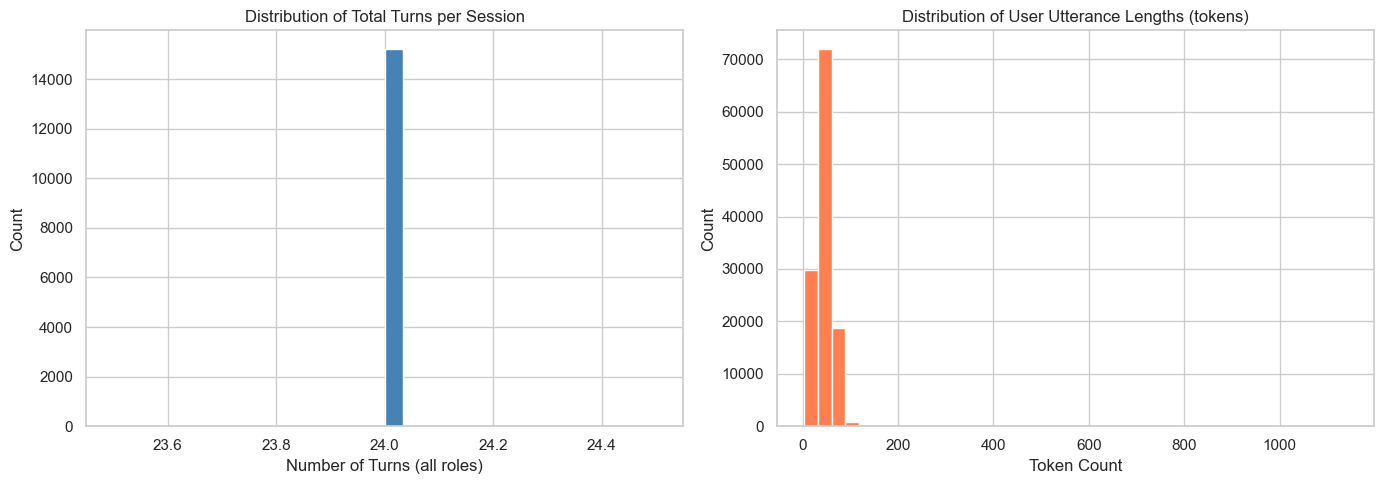

Total sessions: 15,199
Avg turns/session: 24.0
Avg user turns/session: 8.0
Median user utterance length: 45 tokens


In [5]:
# Count turns per session
train_df['num_turns'] = train_df['conversations'].apply(lambda x: len(x))

# Count user utterances (role == 'user') per session
train_df['num_user_turns'] = train_df['conversations'].apply(
    lambda convs: sum(1 for c in convs if c['role'] == 'user')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['num_turns'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Total Turns per Session')
axes[0].set_xlabel('Number of Turns (all roles)')
axes[0].set_ylabel('Count')

# Utterance lengths (user messages only)
user_utterances = []
for convs in train_df['conversations']:
    for c in convs:
        if c['role'] == 'user':
            user_utterances.append(len(c['content'].split()))

axes[1].hist(user_utterances, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribution of User Utterance Lengths (tokens)')
axes[1].set_xlabel('Token Count')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Total sessions: {len(train_df):,}')
print(f'Avg turns/session: {train_df["num_turns"].mean():.1f}')
print(f'Avg user turns/session: {train_df["num_user_turns"].mean():.1f}')
print(f'Median user utterance length: {np.median(user_utterances):.0f} tokens')

## 3. Track Metadata Analysis

In [6]:
tracks_df = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Track-Metadata/data/all_tracks-00000-of-00001.parquet')
print(f'Track catalog size: {len(tracks_df):,}')
print(f'Columns: {list(tracks_df.columns)}')
tracks_df.head()

Track catalog size: 47,071
Columns: ['track_id', 'ISRC', 'track_name', 'artist_name', 'album_name', 'tag_list', 'popularity', 'release_date', 'duration', 'artist_id', 'album_id']


,track_id,ISRC,track_name,artist_name,album_name,tag_list,popularity,release_date,duration,artist_id,album_id
0,97f5eeec-1ec7-4bb9-93e9-a948ee7466fc,[TCABY1497179],[With Rainy Eyes],[Emancipator],[Soon It Will Be Cold Enough],"[relaxing, experimental, goeiepoep, Instrumental, piano, lo-fi, body parts, smooth, life is easy, top quality, ambie...",39.0,2006-12-06,300920,[22f09759-f15c-475b-98aa-00d25e1ed50c],[a204a441-3a18-435a-9652-0ab4192f0d63]
1,cdf6f46e-9399-499f-8347-ac5c98d1fe8a,[USRC11400686],[Time After Time],[The Wind and The Wave],[Covers One],[Alternative],31.0,2015-02-17,279746,[fb6256ac-879a-410e-a3cd-0f8f33eb3b0b],[b5286241-57a0-4c60-8b2d-1af3b2c455eb]
2,e791b24a-8158-49ae-9e4f-b947c11af4de,[USSM19909797],[(I Left My Heart) In San Francisco],[Tony Bennett],"[I Left My Heart In San Francisco, The Essential Tony Bennett]","[pop, jazzyscrooners, soundtrack, playable around robin, Rock, grammy, swing, vocal jazz, easy listening, soft rock,...",59.0,1962-06-18,170960,[753d738e-2688-4e93-a35b-00edc0bdd37d],"[0e7da3cf-9e91-45f1-a25d-c14737e0202b, d8991ecb-db6e-4289-b8d5-2d2f29afd4ca]"
3,935a5d6d-f097-46ff-b6da-2dbdccc706df,[USWB19901570],[Suck My Kiss],[Red Hot Chili Peppers],"[Blood Sugar Sex Magik (Deluxe Version), Blood Sugar Sex Magik]","[energetic, alternative rock, funk metal, music that makes me hott, better than muse, Alternative, favorites, songs ...",66.0,1991-09-24,217133,[6d1b6ccb-41a5-461b-bca9-306182c741bd],[255e26b8-4c61-4bff-805a-a1c8861a101f]
4,6a9e55df-9c41-4e86-ac17-b3aad5ed2617,[USMBR1208744],[Scourge of Iron],[Cannibal Corpse],[Torture],"[jeff young, royal ruckus, Metal, torture, death metal, cannibal corpse, slamming brutal death metal, thrash metal, ...",56.0,2012-03-13,284400,[6ef365f7-b9d7-4a49-ac46-9ccb3fff4a88],"[011990e0-0724-4c73-9c10-d26269c6a1ce, d68f7f33-0782-4e0f-8e07-37d17fd96078]"


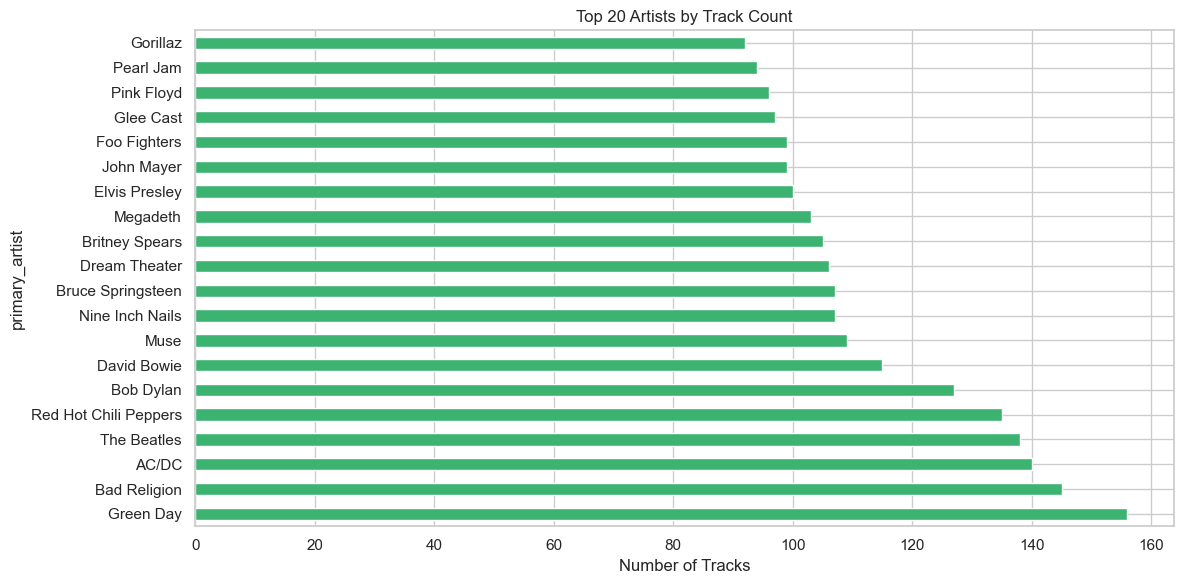

In [7]:
# artist_name is a list — extract first entry for display
tracks_df['primary_artist'] = tracks_df['artist_name'].apply(
    lambda x: x[0] if isinstance(x, (list, np.ndarray)) and len(x) > 0 else str(x)
)

top_artists = tracks_df['primary_artist'].value_counts().head(20)

plt.figure(figsize=(12, 6))
top_artists.plot(kind='barh', color='mediumseagreen')
plt.title('Top 20 Artists by Track Count')
plt.xlabel('Number of Tracks')
plt.tight_layout()
plt.show()

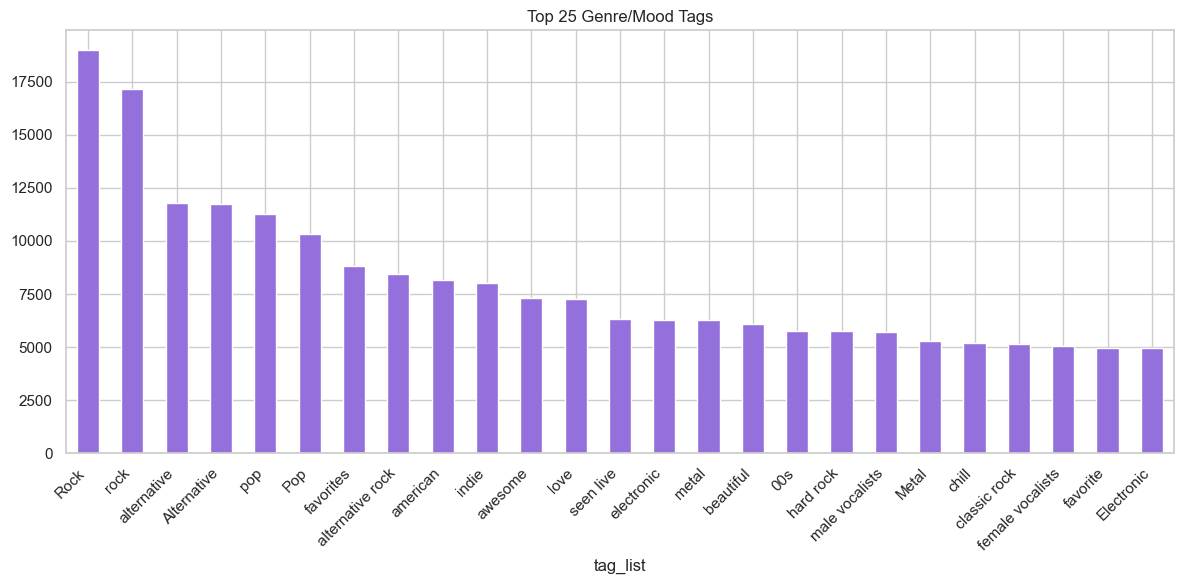

In [8]:
# Tag / Genre distribution — tag_list is a list per track
all_tags = tracks_df['tag_list'].dropna().explode()
top_tags = all_tags.value_counts().head(25)

plt.figure(figsize=(12, 6))
top_tags.plot(kind='bar', color='mediumpurple')
plt.title('Top 25 Genre/Mood Tags')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. User Profile Analysis

In [9]:
users_df = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-User-Metadata/data/all_users-00000-of-00001.parquet')
print(f'Total users: {len(users_df):,}')
users_df.head()

Total users: 8,772


,user_id,age,age_group,country_code,country_name,gender
0,5e51258a-27e3-4b49-aed9-10c9d05f139c,19,10s,BG,Bulgaria,female
1,0c7e49b3-c87b-4759-8da2-cfd400af29bf,31,30s,US,United States,male
2,913ac17d-a698-4da0-96cf-097b6909443e,17,10s,RU,Russia,female
3,b246106b-d26a-47f0-a70f-b17674dd608a,20,20s,FR,France,male
4,68aa6a54-2856-448c-ae2e-785bef3cc7b7,20,20s,BR,Brazil,male


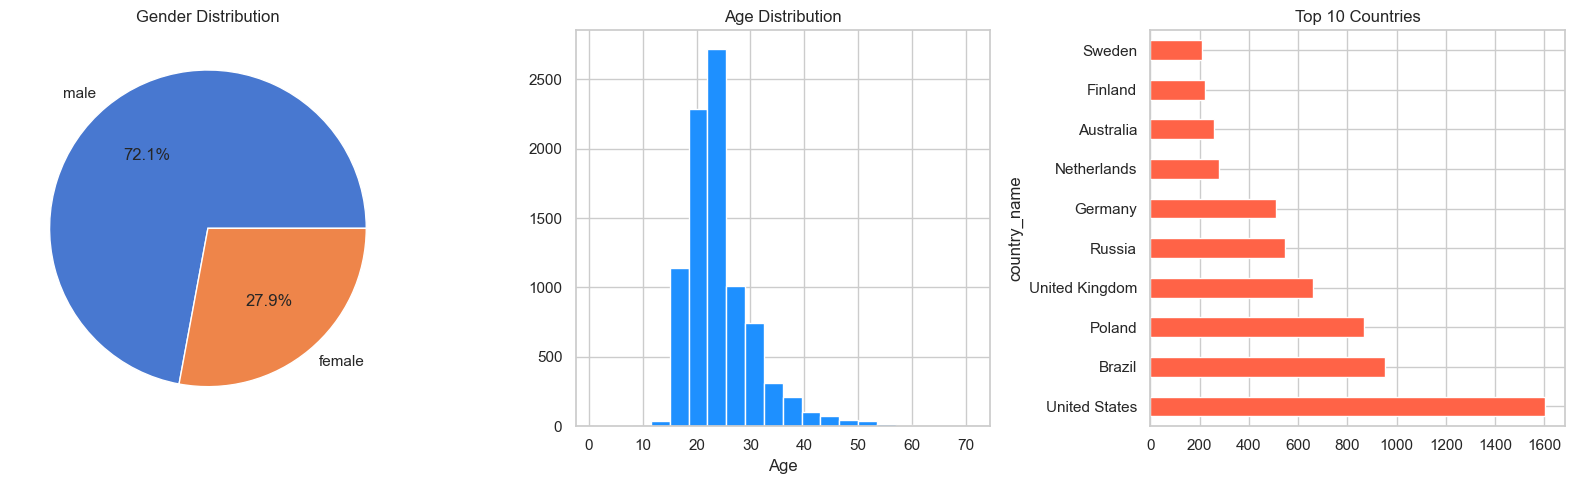

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender
users_df['gender'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%')
axes[0].set_title('Gender Distribution')
axes[0].set_ylabel('')

# Age
axes[1].hist(users_df['age'].dropna(), bins=20, color='dodgerblue', edgecolor='white')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')

# Top countries
users_df['country_name'].value_counts().head(10).plot(kind='barh', ax=axes[2], color='tomato')
axes[2].set_title('Top 10 Countries')

plt.tight_layout()
plt.show()

## 5. Sample Conversations

In [11]:
# Show a full sample conversation
sample = train_df.iloc[0]
print(f'Session: {sample["session_id"]}')
print(f'User: {sample["user_id"]}')
print(f'Date: {sample["session_date"]}')
print(f'Goal: {sample["conversation_goal"]}')
print('=' * 60)
for turn in sample['conversations']:
    role = turn['role'].upper()
    content = turn['content']
    thought = turn.get('thought', '')
    print(f'[Turn {turn["turn_number"]}] {role}: {content}')
    if thought:
        print(f'  💭 Thought: {thought}')
    print()

Session: 9c337a02-15b1-408f-8103-c2f9459b3bed
User: 64ea97af-bbc6-4756-ac94-b931048e5fef
Date: 2011-12-26
Goal: {'category': 'H', 'listener_goal': 'The listener wants to explore different artists and discover new songs from a broad collection, focusing on general moods and styles, without specific genre constraints. They are open to exploring the discographies of artists they find interesting.', 'specificity': 'LL'}
[Turn 1] USER: I want to discover some new artists. Do you have anything that's a bit intense or dramatic?

[Turn 1] MUSIC: 81d9f1d9-3b22-4836-9f06-2140e959e6de
  💭 Thought: You enjoyed the last Alesana track, so I'm sticking with your favorite artist and genre. "The Fiend" carries that same intense post-hardcore energy and screamo vocals that define Alesana's sound.

[Turn 1] ASSISTANT: Awesome! Glad you liked that one. Sticking with the Alesana vibe for you, how about "The Fiend"? It's got that classic intensity and screamo you love from them.

[Turn 2] USER: Oh, Alesana 